In [1]:
import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", 
    "pandas", "numpy", "matplotlib", "seaborn", 
    "sqlalchemy", "psycopg2-binary", "python-dotenv"])

0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv('../.env.local')

engine = create_engine(os.getenv('DATABASE_URL'))
print("Connected!")

Connected!


# Forecast Error Analysis — UK Wind Power (January 2024)

## Objective
I wanted to get a clear picture of how well the WINDFOR model actually predicts UK-wide wind generation. Not just a quick glance at the averages, but really pinning down the mistakes it makes, spotting the situations where it goes off track the most, and seeing if there's any rhyme or reason to when and why those slips happen.

## Data Sources
For the real output I used the FUELHH data straight from Elexon’s BMRS – half-hourly readings, pulled only for wind. The forecasts came from their WINDFOR set, which runs hourly and stretches from the current hour out to two days ahead.

## Scope
I stuck strictly to January 2024. Both files came through the BMRS API and landed in a plain PostgreSQL table so I could slice them easily.

## My Approach
Here’s how I matched everything up. For every half-hour period I cared about, I grabbed the freshest forecast that had been issued at least four hours earlier (their usual lead time). Then I simply subtracted the forecast from what actually rolled in and looked at those differences from three angles: the basic spread of errors (average, middle value, plus the 90th and 99th percentiles to catch the worst days), how the mistakes grew as you looked further ahead, and whether certain hours of the day – say 6 a.m. versus 6 p.m. – threw the model off more consistently than others.

In [3]:
actuals = pd.read_sql("""
    SELECT start_time, generation::float AS actual_mw
    FROM actuals
    ORDER BY start_time
""", engine)

forecasts = pd.read_sql("""
    SELECT start_time, publish_time, generation::float AS forecast_mw
    FROM forecasts
    ORDER BY start_time, publish_time
""", engine)

actuals['start_time'] = pd.to_datetime(actuals['start_time'], utc=True)
forecasts['start_time'] = pd.to_datetime(forecasts['start_time'], utc=True)
forecasts['publish_time'] = pd.to_datetime(forecasts['publish_time'], utc=True)

print(f"Actuals:   {len(actuals)} rows")
print(f"Forecasts: {len(forecasts)} rows")
actuals.head()

Actuals:   1489 rows
Forecasts: 9560 rows


,start_time,actual_mw
0,2023-12-31 23:30:00+00:00,9980.0
1,2024-01-01 00:00:00+00:00,10402.0
2,2024-01-01 00:30:00+00:00,10845.0
3,2024-01-01 01:00:00+00:00,11218.0
4,2024-01-01 01:30:00+00:00,11223.0


In [4]:
# Calc how many hours before each target slot the forecast was published
forecasts['horizon_hrs'] = (
    (forecasts['start_time'] - forecasts['publish_time'])
    .dt.total_seconds() / 3600
).round(1)

print("Horizon range:")
print(f"  Min: {forecasts['horizon_hrs'].min()} hrs")
print(f"  Max: {forecasts['horizon_hrs'].max()} hrs")
print(f"  Mean: {forecasts['horizon_hrs'].mean():.1f} hrs")
print()

# For each target slot, pick the latest forecast published at least 4hrs before
matched = (
    forecasts[forecasts['horizon_hrs'] >= 4]
    .sort_values('publish_time', ascending=False)
    .drop_duplicates(subset='start_time', keep='first')
)

# Join with actuals
df = matched.merge(actuals, on='start_time', how='inner')

# Compute error
df['error'] = df['actual_mw'] - df['forecast_mw']
df['abs_error'] = df['error'].abs()
df['pct_error'] = (df['abs_error'] / df['actual_mw']) * 100

print(f"Matched pairs after 4hr horizon filter: {len(df)}")
df[['start_time', 'actual_mw', 'forecast_mw', 'horizon_hrs', 'error']].head(8)

Horizon range:
  Min: 0.5 hrs
  Max: 48.0 hrs
  Mean: 28.1 hrs

Matched pairs after 4hr horizon filter: 744


,start_time,actual_mw,forecast_mw,horizon_hrs,error
0,2024-01-31 23:00:00+00:00,14595.0,17013.0,24.5,-2418.0
1,2024-01-31 13:00:00+00:00,15997.0,18116.0,14.5,-2119.0
2,2024-01-31 19:00:00+00:00,15812.0,18033.0,20.5,-2221.0
3,2024-01-31 17:00:00+00:00,15683.0,17992.0,18.5,-2309.0
4,2024-01-31 16:00:00+00:00,15762.0,18211.0,17.5,-2449.0
5,2024-01-31 09:00:00+00:00,13747.0,14912.0,10.5,-1165.0
6,2024-01-31 03:00:00+00:00,8175.0,11477.0,4.5,-3302.0
7,2024-01-31 20:00:00+00:00,15684.0,17782.0,21.5,-2098.0


## Step 1: Overall Error Statistics
The matched dataset includes 744 pairs with a forecast lead time of at least 4 hours. Before plotting anything, I’m checking the raw numbers to see how the model is actually performing.

Every error in the initial sample is negative, meaning the model predicted more generation than what actually occurred. I need to verify if this overestimation is a systematic bias across the entire dataset or just a fluke in these specific rows.

In [5]:
stats = {
    'Mean error (MW)':              df['error'].mean(),
    'Median error (MW)':            df['error'].median(),
    'Mean absolute error (MW)':     df['abs_error'].mean(),
    'Median absolute error (MW)':   df['abs_error'].median(),
    'P90 absolute error (MW)':      df['abs_error'].quantile(0.90),
    'P99 absolute error (MW)':      df['abs_error'].quantile(0.99),
    'Std deviation (MW)':           df['error'].std(),
    'Mean % error':                 df['pct_error'].mean(),
}

for k, v in stats.items():
    print(f"{k:35s}: {v:8.1f}")

Mean error (MW)                    :  -1179.9
Median error (MW)                  :   -921.0
Mean absolute error (MW)           :   1826.6
Median absolute error (MW)         :   1453.5
P90 absolute error (MW)            :   3956.4
P99 absolute error (MW)            :   6072.9
Std deviation (MW)                 :   2129.8
Mean % error                       :      inf


## Interpretation
The numbers confirm what the sample rows hinted at. Both the mean and median error are negative, so the model consistently over-forecasts generation rather than making random mistakes in both directions. It has a directional bias.
A few things worth thinking through: What might cause this kind of systematic over-forecasting? Is a 1,826 MW average error actually significant, or is it modest relative to typical generation levels in this dataset? And what does a P99 of 6,072 MW mean practically for a grid operator who is relying on these forecasts to make decisions?

Rows removed due to zero actual: 1
Mean % error (cleaned): 17.7%
Median % error (cleaned): 15.4%


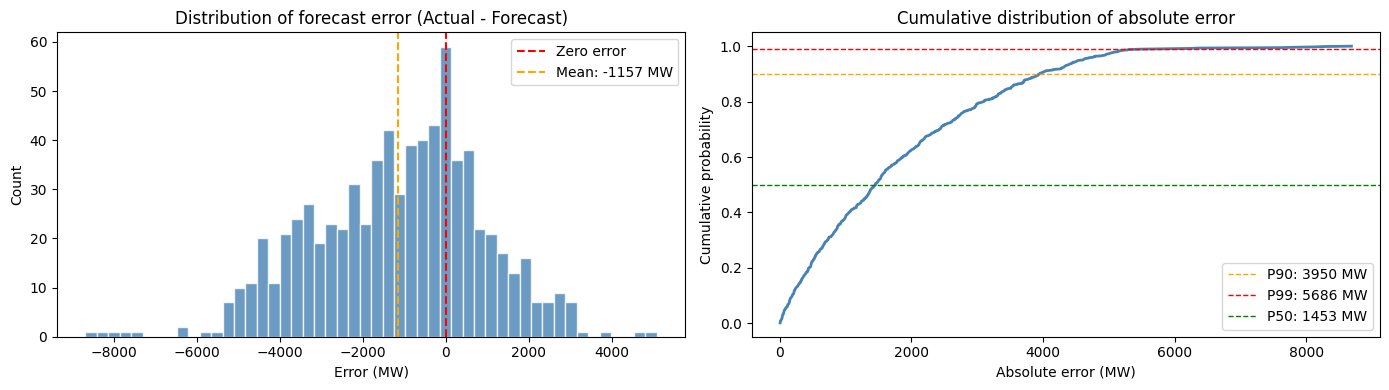

In [6]:
# Fix inf error
df_clean = df[df['actual_mw'] > 0].copy()
df_clean['pct_error'] = (df_clean['abs_error'] / df_clean['actual_mw']) * 100

print(f"Rows removed due to zero actual: {len(df) - len(df_clean)}")
print(f"Mean % error (cleaned): {df_clean['pct_error'].mean():.1f}%")
print(f"Median % error (cleaned): {df_clean['pct_error'].median():.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Signed error histogram
axes[0].hist(df_clean['error'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[0].axvline(df_clean['error'].mean(), color='orange', linestyle='--', 
                linewidth=1.5, label=f"Mean: {df_clean['error'].mean():.0f} MW")
axes[0].set_title('Distribution of forecast error (Actual - Forecast)')
axes[0].set_xlabel('Error (MW)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Absolute error CDF
sorted_err = np.sort(df_clean['abs_error'])
cdf = np.arange(1, len(sorted_err) + 1) / len(sorted_err)
axes[1].plot(sorted_err, cdf, color='steelblue', linewidth=2)
axes[1].axhline(0.90, color='orange', linestyle='--', linewidth=1, label=f"P90: {df_clean['abs_error'].quantile(0.90):.0f} MW")
axes[1].axhline(0.99, color='red', linestyle='--', linewidth=1, label=f"P99: {df_clean['abs_error'].quantile(0.99):.0f} MW")
axes[1].axhline(0.50, color='green', linestyle='--', linewidth=1, label=f"P50: {df_clean['abs_error'].quantile(0.50):.0f} MW")
axes[1].set_title('Cumulative distribution of absolute error')
axes[1].set_xlabel('Absolute error (MW)')
axes[1].set_ylabel('Cumulative probability')
axes[1].legend()

plt.tight_layout()
plt.show()

## What the error distribution tells us
The histogram makes the bias visible: the model consistently over-predicts generation. A mean error of -1,157 MW means grid operators were told to expect roughly 1,200 MW more wind than actually showed up. The median percentage error of 15.4% puts that in plain terms: if actual output was 10,000 MW, the forecast was typically calling 11,500 MW.
The P99 absolute error of 5,686 MW is the more worrying figure. In the worst 1% of cases, the model was off by nearly 6 GW, which is a gap that requires real backup capacity to cover.

In [7]:
# Build error pairs for every horizon leve
all_matched = (
    forecasts
    .sort_values('publish_time', ascending=False)
    .drop_duplicates(subset=['start_time', 'horizon_hrs'], keep='first')
    .merge(actuals, on='start_time', how='inner')
)

all_matched['error'] = all_matched['actual_mw'] - all_matched['forecast_mw']
all_matched['abs_error'] = all_matched['error'].abs()

# Bin horizons into 4-hour buckets
bins = list(range(0, 52, 4))
labels = [f"{i}-{i+4}h" for i in range(0, 48, 4)]
all_matched['horizon_bin'] = pd.cut(all_matched['horizon_hrs'], bins=bins, labels=labels)

horizon_stats = all_matched.groupby('horizon_bin', observed=True)['abs_error'].agg(
    mean='mean',
    median='median',
    p90=lambda x: x.quantile(0.90),
    p99=lambda x: x.quantile(0.99),
).reset_index()

print(horizon_stats.to_string(index=False))

horizon_bin        mean  median    p90     p99
       0-4h 1819.983607  1363.0 4300.2 5317.62
       4-8h 1932.058997  1443.0 4395.0 7719.36
      8-12h 1908.099391  1326.0 4416.6 7594.16
     12-16h 1914.026836  1371.5 4364.8 7197.52
     16-20h 1937.652973  1517.0 4268.6 7380.76
     20-24h 1938.379415  1599.0 4205.0 7389.50
     24-28h 2006.015121  1722.0 4209.1 6815.54
     28-32h 2009.494960  1828.5 4108.6 6859.92
     32-36h 2086.013105  1933.0 4026.0 7494.54
     36-40h 2134.915323  1988.5 4023.8 7384.05
     40-44h 2320.848790  2217.0 4127.9 8261.08
     44-48h 2401.609781  2248.0 4309.0 7747.00


## Step 2: How Error Changes With Forecast Horizon
I expected error to grow sharply with longer horizons since wind is weather-driven and harder to predict further out. The direction holds, but the degradation is surprisingly gradual: mean absolute error goes from around 1,820 MW at short horizons to about 2,400 MW at 44-48 hours, a 32% increase across the full range.
Worth noting: even 0-4 hour forecasts already carry ~1,800 MW of error. Is the slow degradation good news, or does it just mean the model is already struggling at short range? The P99 column is also noticeably more volatile across horizons, which raises questions about how the model behaves in its worst cases.

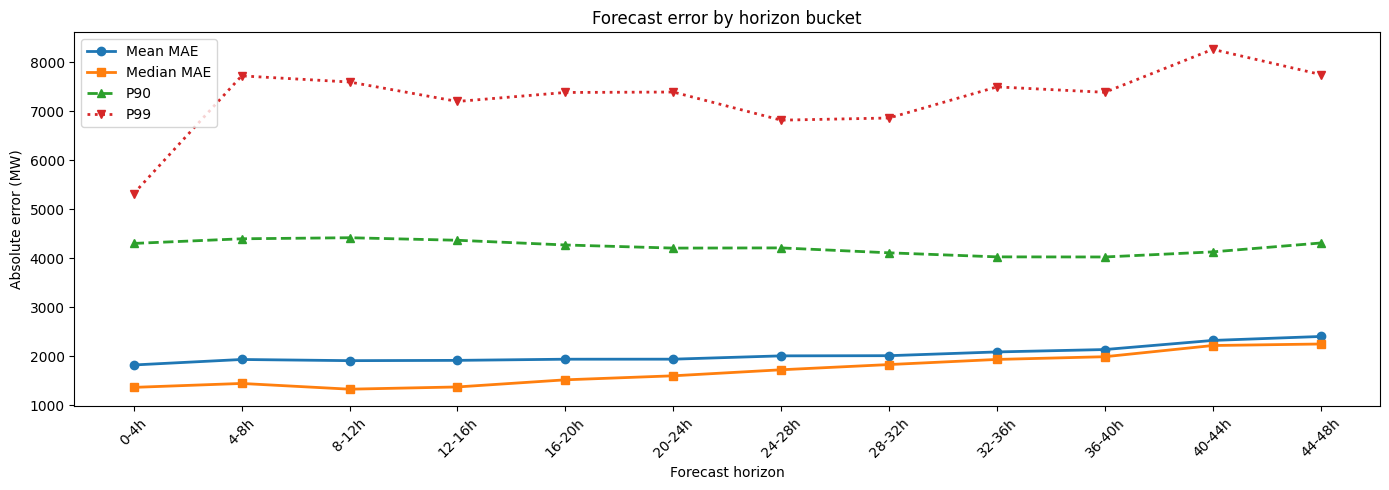

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

x = range(len(horizon_stats))

ax.plot(x, horizon_stats['mean'],   marker='o', linewidth=2, label='Mean MAE')
ax.plot(x, horizon_stats['median'], marker='s', linewidth=2, label='Median MAE')
ax.plot(x, horizon_stats['p90'],    marker='^', linewidth=2, linestyle='--', label='P90')
ax.plot(x, horizon_stats['p99'],    marker='v', linewidth=2, linestyle=':', label='P99')

ax.set_xticks(x)
ax.set_xticklabels(horizon_stats['horizon_bin'], rotation=45)
ax.set_xlabel('Forecast horizon')
ax.set_ylabel('Absolute error (MW)')
ax.set_title('Forecast error by horizon bucket')
ax.legend()

plt.tight_layout()
plt.show()

## What the horizon chart tells us
Mean and median error both climb steadily with horizon, as expected, but the degradation is modest. More interesting is the P90 line, which stays nearly flat across all horizons. That means 90% of forecasts hold similar accuracy regardless of how far ahead they were made. The horizon mostly affects the tail: the worst forecasts get worse at longer ranges, but typical forecasts don't degrade much.
The P99 line is erratic rather than trend-following, suggesting extreme errors come from sudden unexpected weather events, not forecast lead time.
Given that P90 stays flat, the forecast stays reasonably reliable across the full 48-hour range for typical conditions. The real concern is not horizon length but the tail behaviour. Even at 4 hours out, a bad weather event can produce a 6 GW error.
So rather than drawing a hard cutoff at a specific horizon, a grid operator would be better served by treating any forecast beyond 24 hours with wider uncertainty margins and always keeping backup capacity ready for the tail cases, regardless of horizon.

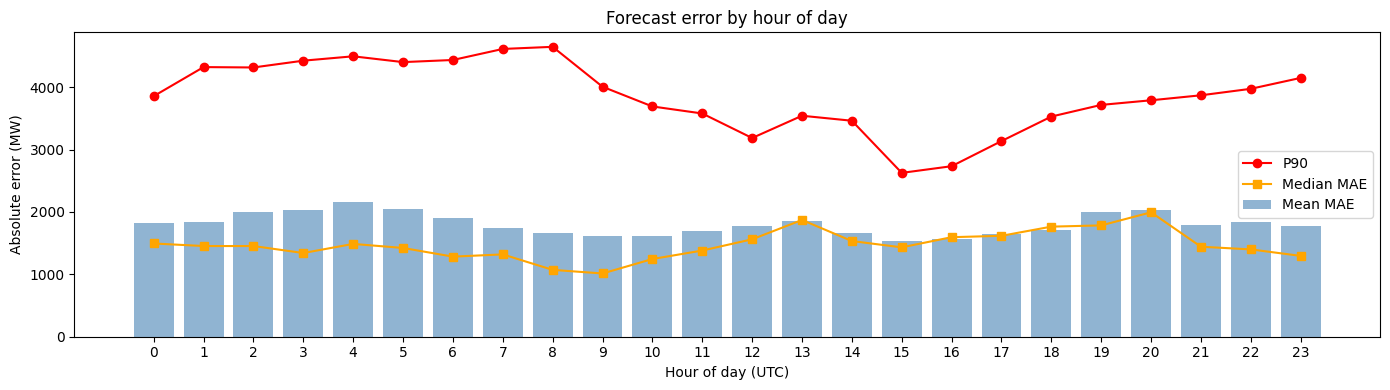


Hourly stats:
 hour        mean  median    p90
    0 1830.806452  1495.0 3857.0
    1 1842.741935  1454.0 4323.0
    2 2006.387097  1454.0 4317.0
    3 2026.451613  1342.0 4426.0
    4 2152.064516  1488.0 4496.0
    5 2054.451613  1423.0 4403.0
    6 1909.709677  1284.0 4437.0
    7 1745.838710  1320.0 4614.0
    8 1656.580645  1072.0 4648.0
    9 1611.193548  1014.0 4008.0
   10 1622.903226  1246.0 3692.0
   11 1688.033333  1382.0 3579.3
   12 1770.419355  1562.0 3186.0
   13 1859.935484  1872.0 3543.0
   14 1658.419355  1534.0 3463.0
   15 1530.935484  1433.0 2627.0
   16 1572.870968  1596.0 2734.0
   17 1645.903226  1618.0 3137.0
   18 1704.000000  1765.0 3530.0
   19 1997.838710  1785.0 3717.0
   20 2025.677419  1995.0 3791.0
   21 1796.258065  1443.0 3871.0
   22 1831.451613  1400.0 3975.0
   23 1772.516129  1296.0 4150.0


In [9]:
df_clean['hour'] = df_clean['start_time'].dt.hour

hourly = df_clean.groupby('hour')['abs_error'].agg(
    mean='mean',
    median='median',
    p90=lambda x: x.quantile(0.90)
).reset_index()

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(hourly['hour'], hourly['mean'], alpha=0.6, color='steelblue', label='Mean MAE')
ax.plot(hourly['hour'], hourly['p90'], color='red', marker='o', 
        linewidth=1.5, label='P90')
ax.plot(hourly['hour'], hourly['median'], color='orange', marker='s', 
        linewidth=1.5, label='Median MAE')

ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('Absolute error (MW)')
ax.set_title('Forecast error by hour of day')
ax.set_xticks(range(0, 24))
ax.legend()

plt.tight_layout()
plt.show()

print("\nHourly stats:")
print(hourly.to_string(index=False))

## Step 3: Error by Hour of Day
Early morning hours (3-5 UTC) have the highest mean error, likely because overnight wind patterns are harder to predict with fewer observations available. Mid-morning (9-11 UTC) is the model's best window, with mean and median error both at their lowest. P90 dips noticeably around 15-16 UTC, meaning extreme misses are less common in the afternoon.
The overall variation is not dramatic, which suggests time of day is a secondary factor compared to the systematic over-forecasting bias seen earlier.
The error pattern does work against demand peaks. Morning demand is high and that is also when the model is least reliable, which is a bad combination for grid operators who need accurate wind forecasts precisely when balancing is hardest.
The hour 8 vs hour 15 P90 gap is likely weather-driven. Morning hours in the UK often see more variable wind conditions as overnight atmospheric stability breaks down. By mid-afternoon, wind patterns tend to be more consistent and easier to forecast, which would explain why extreme errors are much less common around hour 15.

In [10]:
# Summary table for the conclusions section
print("=" * 55)
print("FORECAST ERROR ANALYSIS SUMMARY")
print("=" * 55)
print(f"\nDataset: January 2024, 4hr+ horizon matched pairs")
print(f"Total matched slots analysed: {len(df_clean)}")
print()
print("OVERALL ERROR")
print(f"  Mean error (bias):     {df_clean['error'].mean():>8.0f} MW  (negative = over-forecast)")
print(f"  Median error:          {df_clean['error'].median():>8.0f} MW")
print(f"  Mean absolute error:   {df_clean['abs_error'].mean():>8.0f} MW")
print(f"  P90 absolute error:    {df_clean['abs_error'].quantile(0.90):>8.0f} MW")
print(f"  P99 absolute error:    {df_clean['abs_error'].quantile(0.99):>8.0f} MW")
print(f"  Median % error:        {df_clean['pct_error'].median():>8.1f}%")
print()
print("HORIZON EFFECT")
print(f"  MAE at  0-4h horizon:  {horizon_stats[horizon_stats['horizon_bin']=='0-4h']['mean'].values[0]:>8.0f} MW")
print(f"  MAE at 44-48h horizon: {horizon_stats[horizon_stats['horizon_bin']=='44-48h']['mean'].values[0]:>8.0f} MW")
degradation = ((horizon_stats[horizon_stats['horizon_bin']=='44-48h']['mean'].values[0] / 
                horizon_stats[horizon_stats['horizon_bin']=='0-4h']['mean'].values[0]) - 1) * 100
print(f"  Degradation:           {degradation:>8.1f}%")
print()
print("HOUR OF DAY")
print(f"  Best hour (lowest MAE): {hourly.loc[hourly['mean'].idxmin(), 'hour']:>3.0f}:00 UTC  ({hourly['mean'].min():.0f} MW)")
print(f"  Worst hour (highest MAE): {hourly.loc[hourly['mean'].idxmax(), 'hour']:>1.0f}:00 UTC  ({hourly['mean'].max():.0f} MW)")

FORECAST ERROR ANALYSIS SUMMARY

Dataset: January 2024, 4hr+ horizon matched pairs
Total matched slots analysed: 743

OVERALL ERROR
  Mean error (bias):        -1157 MW  (negative = over-forecast)
  Median error:              -919 MW
  Mean absolute error:       1805 MW
  P90 absolute error:        3950 MW
  P99 absolute error:        5686 MW
  Median % error:            15.4%

HORIZON EFFECT
  MAE at  0-4h horizon:      1820 MW
  MAE at 44-48h horizon:     2402 MW
  Degradation:               32.0%

HOUR OF DAY
  Best hour (lowest MAE):  15:00 UTC  (1531 MW)
  Worst hour (highest MAE): 4:00 UTC  (2152 MW)


## Conclusions

### Key findings
**1. The model has a systematic over-forecasting bias**
The mean error is -1,157 MW and median is -919 MW. Both are negative, meaning 
the model almost always predicts more generation than actually occurs. This is 
not random noise — it is a consistent directional bias across the entire month.

**2. Typical errors are significant in absolute terms**
A median absolute error of 1,453 MW on a system where generation ranges from 
roughly 3,000 to 16,000 MW represents a ~15% typical miss. Grid operators 
relying on this forecast need to carry at least 1,500-2,000 MW of backup 
reserve to cover typical forecast errors.

**3. Horizon degrades accuracy but not dramatically**
Error grows by only 32% from the shortest to longest horizon (1,820 MW to 
2,402 MW). The model does not collapse at long ranges — it degrades gradually. 
This suggests the model is useful even at 24-48hr horizons, just less precise.

**4. Extreme errors are weather-driven, not horizon-driven**
The P99 error of 5,686 MW does not follow the horizon trend cleanly. Extreme 
outliers appear to be caused by sudden weather events the model failed to 
capture, regardless of lead time.

**5. Time of day has a moderate effect**
The model performs best at 15:00 UTC (MAE 1,531 MW) and worst at 04:00 UTC 
(MAE 2,152 MW). Early morning hours are harder to forecast, likely due to 
overnight wind pattern shifts with fewer real-time observations to correct the model.

### Implications for grid operators
A grid operator using this forecast at the default 4-hour horizon should:
- Assume generation will be ~1,200 MW lower than forecast on average
- Hold at least 2,000 MW of fast-response backup reserve
- Be prepared for errors up to 5,700 MW in rare weather events

### Limitations
This analysis covers January 2024 only. January is a high-wind month in the UK 
and may not represent summer conditions when wind is lower and more variable. 
A fuller analysis would cover 12+ months of data.